# Task 2.2 — Visualizing & Analyzing Patch Attention

In this notebook, we analyze Vision Transformer self-attention mechanisms:
1. **Configure the model** to output attention weights (`output_attentions=True`).
2. **Focus on the CLS token's attention.** The special learnable `[CLS]` token is appended to the sequence of 196 patch embeddings, and its output is used for classification.
3. **Extract raw final-layer attention AND Attention Rollout (Abnar & Zuidema, 2020)** across all 12 transformer layers ($V_l = 0.5 A_l + 0.5 I$).
4. **Compare naive final layer attention vs. Attention Rollout** to produce crisp, high-resolution object saliency heatmaps.
5. **Analyze per-head attention specialization** (low-entropy boundary heads vs high-entropy context heads) and layer-by-layer attention evolution.
6. **Perform empirical comparison** against CNN attribution methods (CAM / Grad-CAM).

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from task2_vit.src.load_vit import load_vit, preprocess_image, get_imagenet_labels, download_sample_images, load_sample_images
from task2_vit.src.attention import (
    extract_cls_attention,
    extract_attention_rollout,
    extract_per_head_attention,
    extract_attention_across_layers,
    plot_attention_methods_comparison,
    plot_per_head_attention,
    plot_attention_across_layers,
    plot_attention_entropy,
    plot_top_bottom_patches
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model, processor = load_vit('google/vit-base-patch16-224')
model.to(device)
id2label = get_imagenet_labels(model)

# Load sample images
download_sample_images()
images = load_sample_images()
print(f'Loaded {len(images)} images')

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 6275.80it/s]


Loaded 3 images


### Raw Final-Layer Attention vs. Attention Rollout Comparison
For each image, we compare:
1. **Raw Final-Layer Mean Attention:** Averages head attention in Layer 12 only (can be diffuse due to global background heads).
2. **Attention Rollout (Abnar & Zuidema, 2020):** Recursively multiplies residual-adjusted attention matrices ($V_l = 0.5 A_l + 0.5 I$) across all 12 Transformer layers to track true information flow into the `[CLS]` token.
3. **Attention Rollout Heatmap Overlay:** High-contrast jet overlay showing precise target object focus.

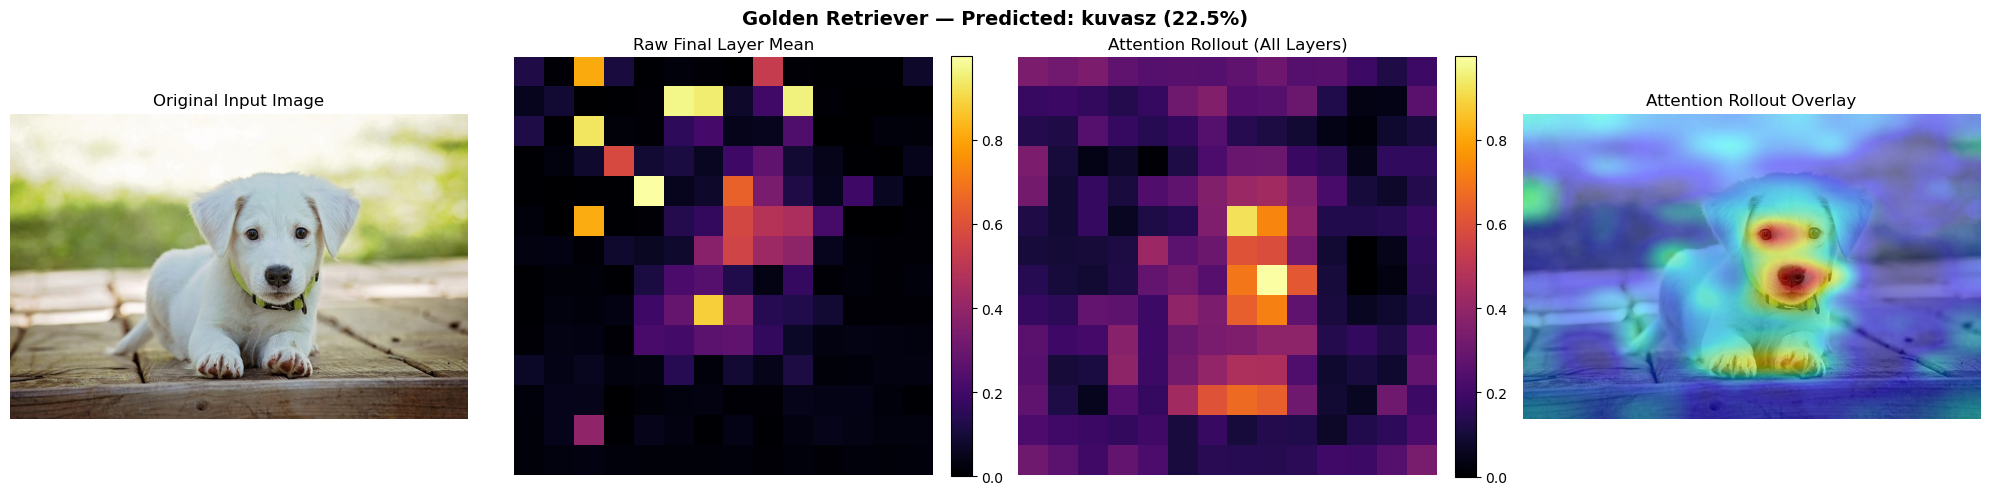

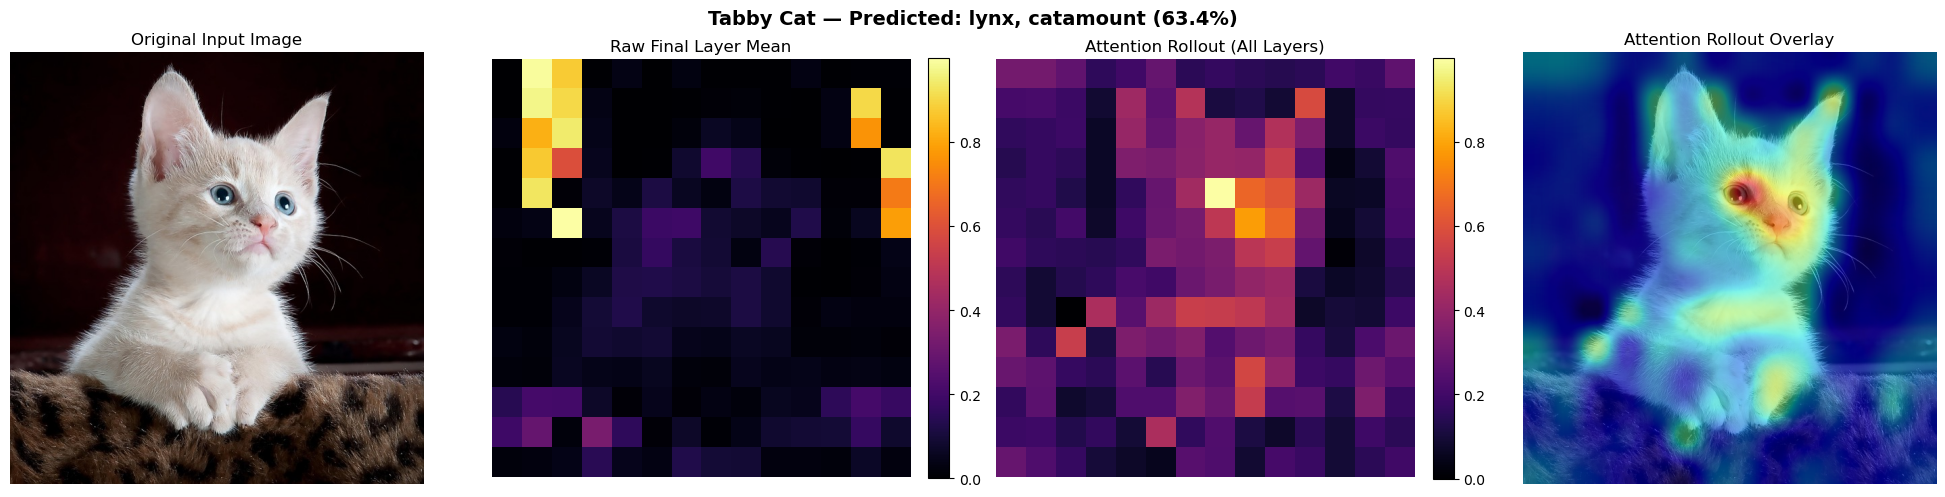

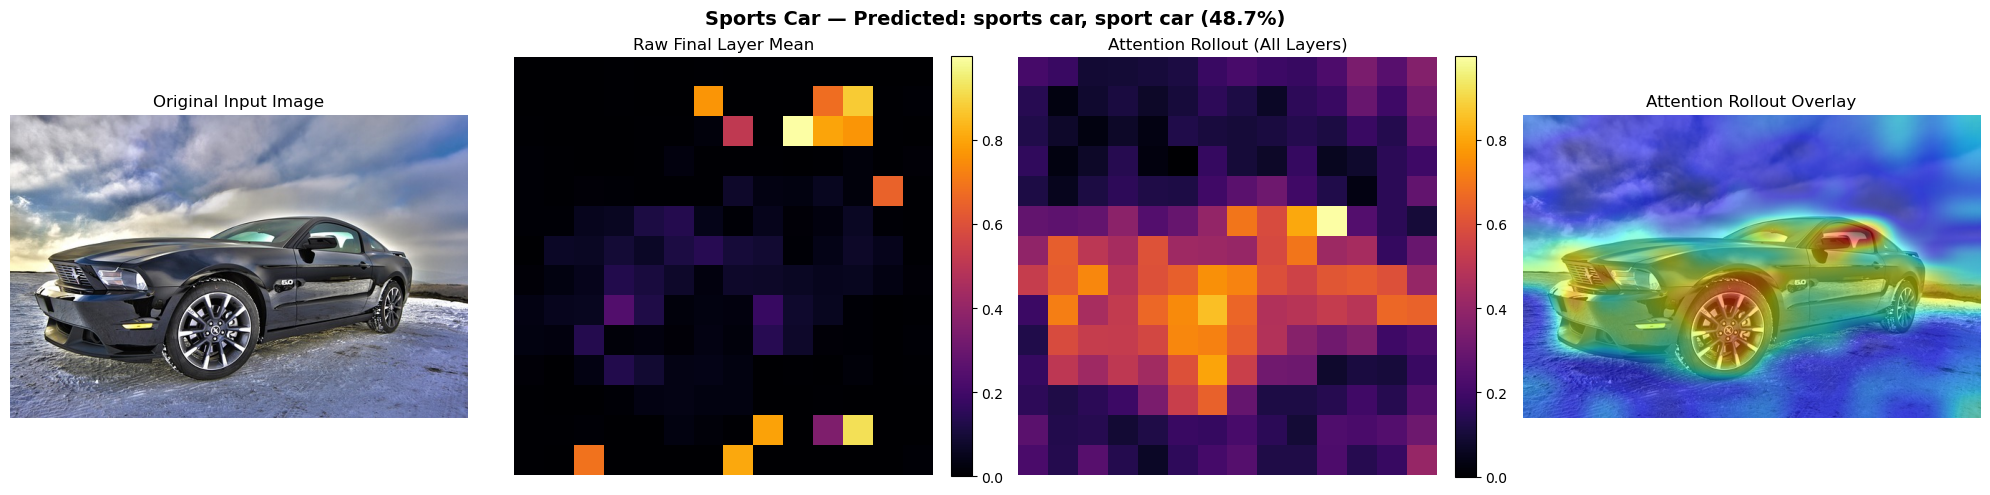

In [2]:
for img, desc in images:
    pixel_values = preprocess_image(processor, img).to(device)
    raw_grid, logits = extract_cls_attention(model, pixel_values)
    rollout_grid, _ = extract_attention_rollout(model, pixel_values)

    probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    top1_idx = probs.argmax()
    top1_label = id2label.get(top1_idx, id2label.get(str(top1_idx), f'Class {top1_idx}'))
    top1_prob = probs[top1_idx]

    safe_name = desc.lower().replace(' ', '_')
    plot_attention_methods_comparison(
        img, raw_grid, rollout_grid,
        title=f'{desc} — Predicted: {top1_label} ({top1_prob*100:.1f}%)',
        save_path=f'../results/figures/attention_comparison_{safe_name}.png'
    )

### Per-Head Attention Analysis (Final Layer)
Each of the 12 attention heads in the final transformer layer may specialize in different visual features: some capture object boundaries, others attend to textures, some are globally diffuse.

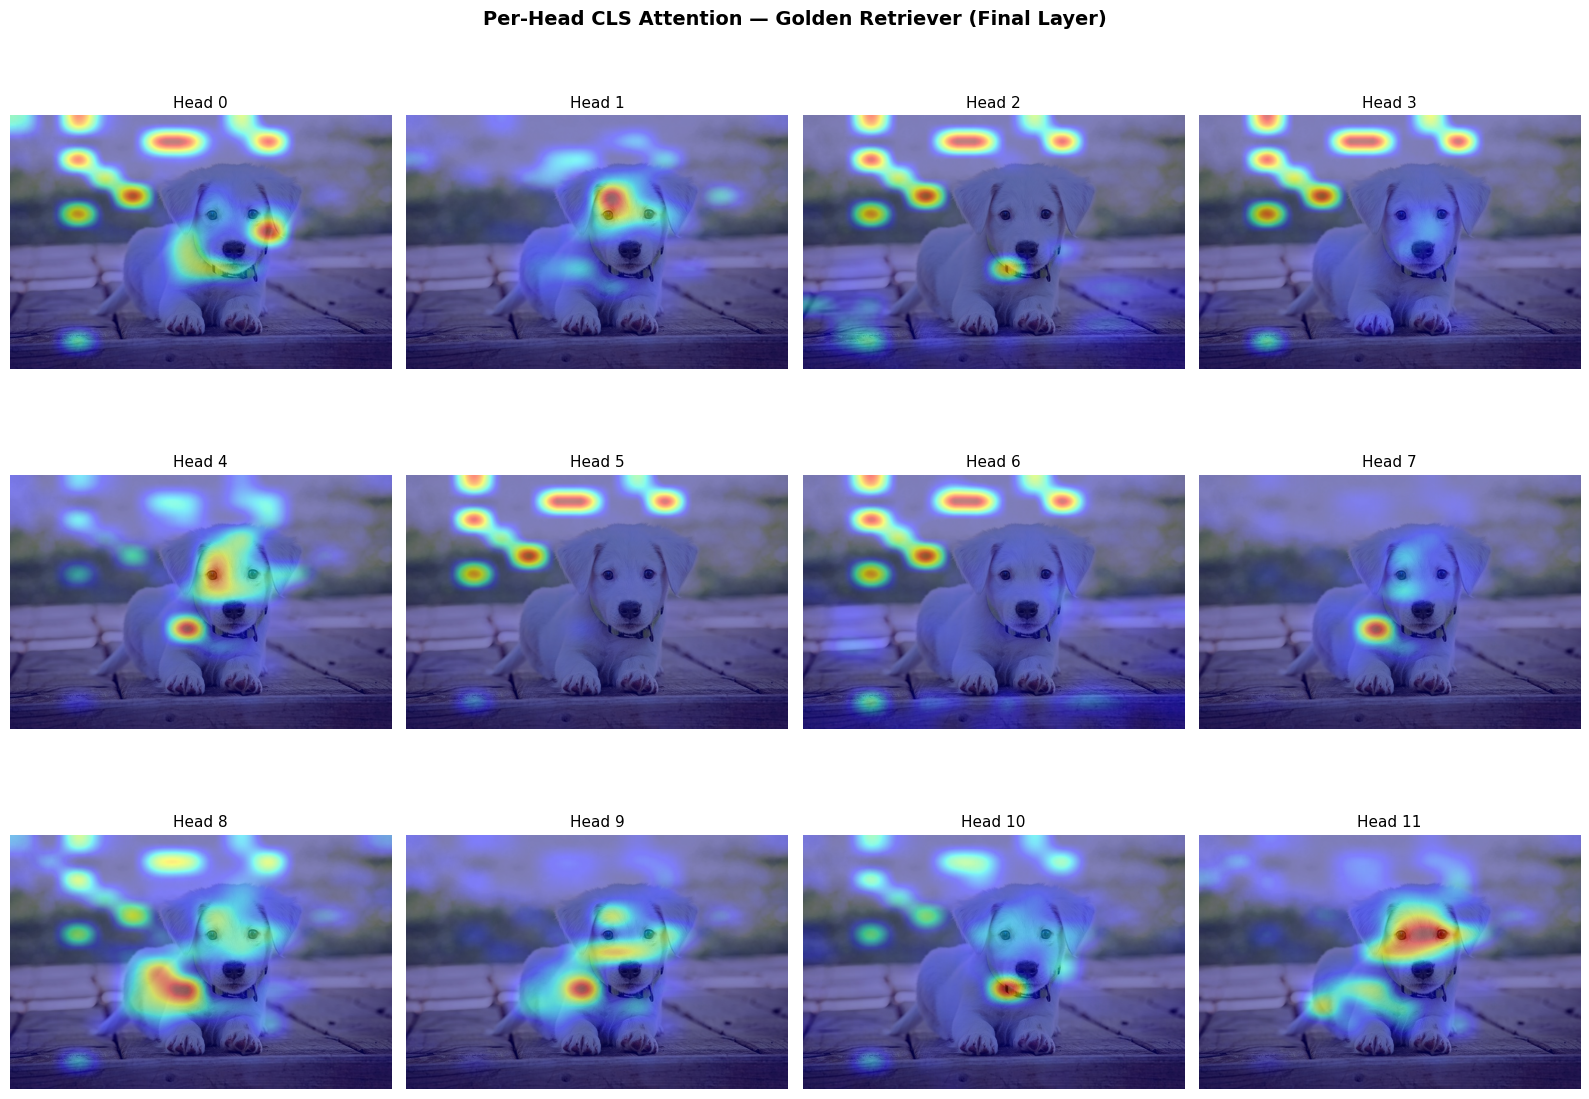

In [3]:
# Use the first image for detailed per-head analysis
img, desc = images[0]
pixel_values = preprocess_image(processor, img).to(device)
head_grids, _ = extract_per_head_attention(model, pixel_values, layer_idx=-1)

plot_per_head_attention(
    img, head_grids,
    save_path=f'../results/figures/per_head_attention_{desc.lower().replace(" ", "_")}.png',
    title=f'Per-Head CLS Attention — {desc} (Final Layer)'
)

### Attention Evolution Across Transformer Layers
Visualize how the CLS token's attention transitions from **diffuse/local** in early layers to **focused/semantic** in deeper layers. We extract head-averaged CLS attention from layers 1, 4, 8, and 12.

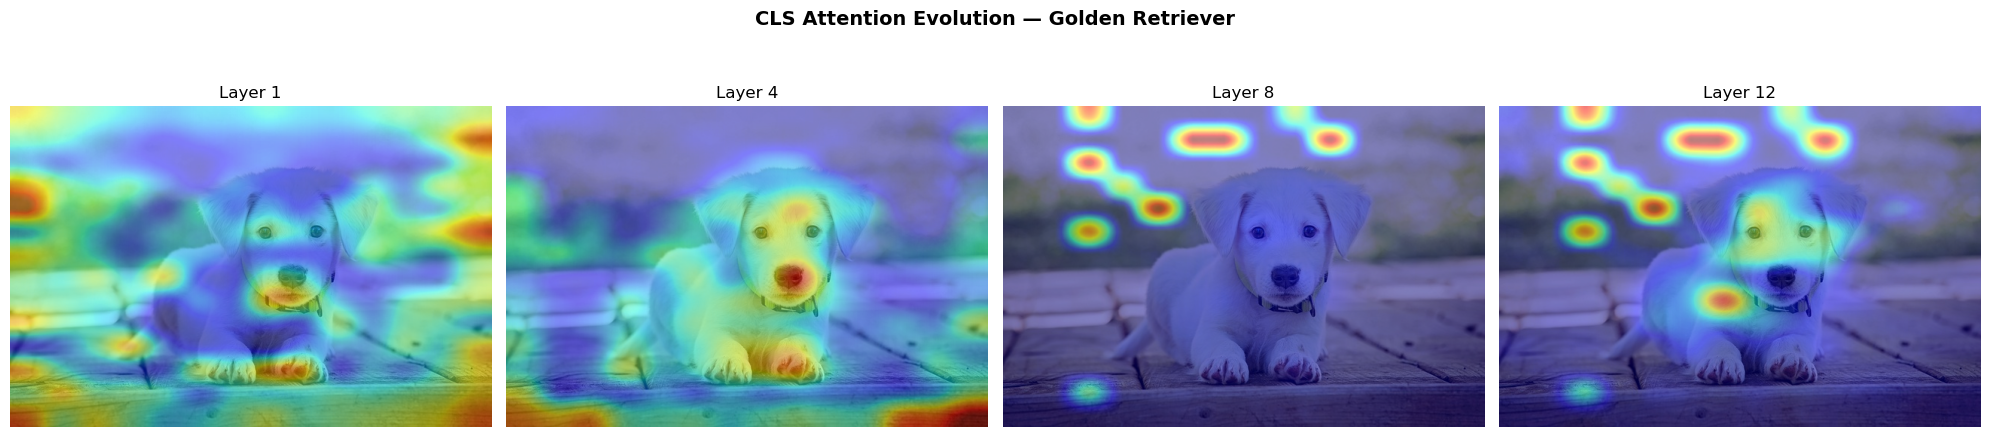

In [4]:
img, desc = images[0]
pixel_values = preprocess_image(processor, img).to(device)
layer_maps = extract_attention_across_layers(model, pixel_values, layer_indices=[0, 3, 7, 11])

plot_attention_across_layers(
    img, layer_maps,
    save_path=f'../results/figures/attention_layer_evolution_{desc.lower().replace(" ", "_")}.png',
    title=f'CLS Attention Evolution — {desc}'
)

### Per-Head Attention Entropy Analysis
Shannon entropy of each head's CLS→patch attention distribution. **Low entropy** = sharply focused head; **High entropy** = diffuse/global head.

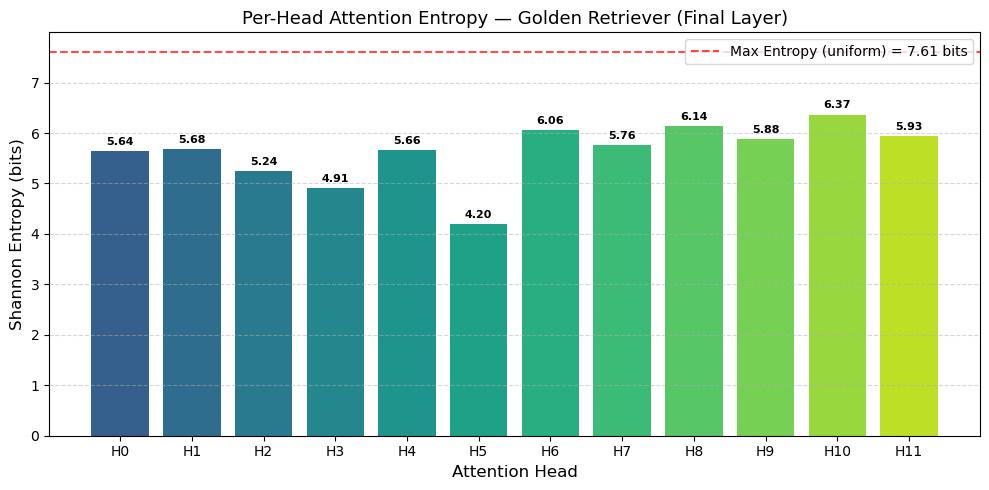

In [5]:
img, desc = images[0]
pixel_values = preprocess_image(processor, img).to(device)

plot_attention_entropy(
    model, pixel_values,
    save_path=f'../results/figures/attention_entropy_{desc.lower().replace(" ", "_")}.png',
    title=f'Per-Head Attention Entropy — {desc} (Final Layer)'
)

### Top & Bottom Attended Patches
Highlight the **top-10 most attended** (green) and **bottom-10 least attended** (red) patches to show what the model focuses on vs. ignores.

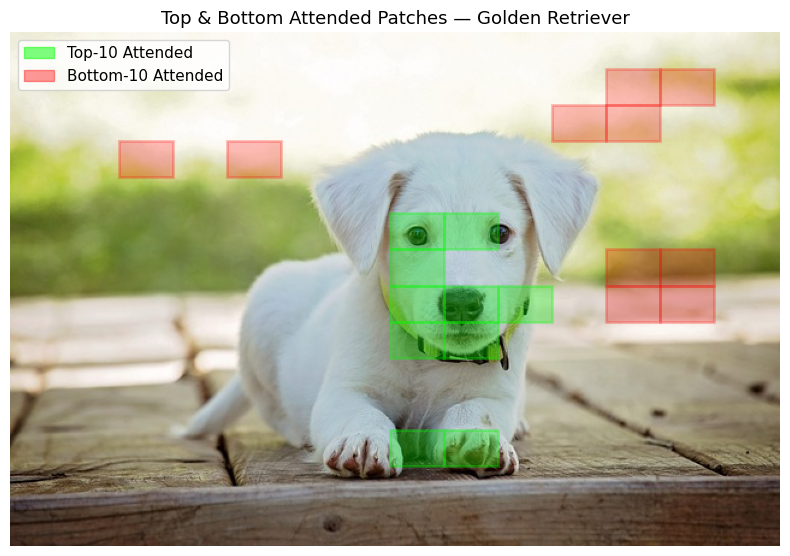

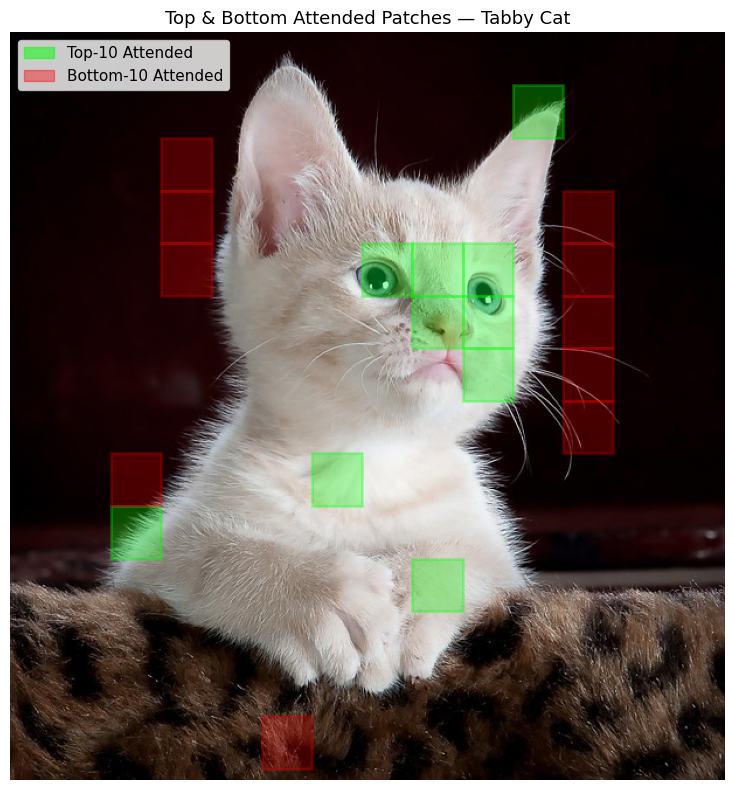

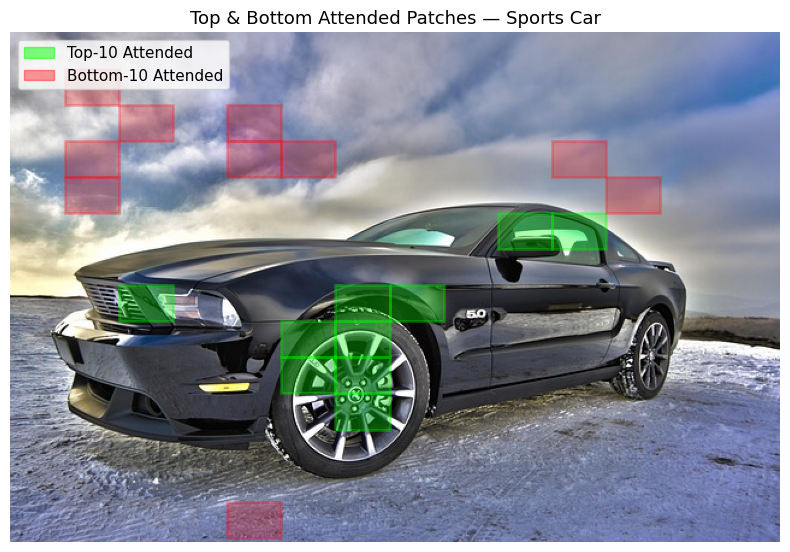

In [6]:
for img, desc in images:
    pixel_values = preprocess_image(processor, img).to(device)
    rollout_grid, _ = extract_attention_rollout(model, pixel_values)

    safe_name = desc.lower().replace(' ', '_')
    plot_top_bottom_patches(
        img, rollout_grid,
        top_k=10, bottom_k=10,
        save_path=f'../results/figures/top_bottom_patches_{safe_name}.png',
        title=f'Top & Bottom Attended Patches — {desc}'
    )